## Name: Mustafa Erdem
## Date : 05/04/2026

### Sentiment Analysis of YouTube Comments
## Research Question
Are viewers reacting positively or negatively to this YouTube video 
https://www.youtube.com/watch?v=ix9cRaBkVe0&t=8642s ?

## Problem Description
This project uses the YouTube Data API v3 and natural language processing techniques to analyze the sentiment of YouTube comments.

## Summary
More than 200 comments were collected, cleaned, and analyzed using TextBlob and NaiveBayesAnalyzer. The results were visualized using graphs and a word cloud.

In [1]:
from importlib.metadata import version
from googleapiclient.discovery import build
import pandas as pd
import re
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

print("google-api-python-client:", version("google-api-python-client"))
print("pandas:", version("pandas"))
print("textblob:", version("textblob"))
print("matplotlib:", version("matplotlib"))
print("nltk:", version("nltk"))
print("wordcloud:", version("wordcloud"))

google-api-python-client: 2.196.0
pandas: 3.0.2
textblob: 0.20.0
matplotlib: 3.10.9
nltk: 3.9.4
wordcloud: 1.9.6


In [ ]:
API_KEY = "******************************" 

### YouTube API Setup
This creates a connection to the YouTube Data API v3 using the googleapiclient library. It sets up the service object that allows the program to fetch data from YouTube using an API key.

In [3]:
youtube = build(
    serviceName="youtube",
    version="v3",
    developerKey=API_KEY
)

### Video Used for Analysis

The comments were collected from the following YouTube video:

https://www.youtube.com/watch?v=ix9cRaBkVe0

This video was selected as the data source for sentiment analysis, and up to 200 comments were extracted from it for processing.

In [4]:
VIDEO_ID = "ix9cRaBkVe0" 
MAX_RESULTS = 200

### YouTube Data Collection (Using YouTube Data API v3)

In this section, I used the YouTube Data API v3 to collect comments from a selected video. The goal was to gather real user-generated text data for sentiment analysis.

The API request retrieves top-level comments from the video using pagination to ensure that multiple pages of results are collected. Since the API limits the number of results per request to 100, a loop is used to continue fetching data until the desired number of comments (200) is reached or no more data is available.

Each comment is extracted from the response JSON structure and stored in a Python list for further processing.

In [5]:
comments = []


request = youtube.commentThreads().list(
    part="snippet", 
    videoId=VIDEO_ID,
    maxResults=100,  
    textFormat="plainText" 
)

while request and len(comments) < MAX_RESULTS: 
    response = request.execute() 
    
    for item in response["items"]: 
        comment = item["snippet"]["topLevelComment"]["snippet"]["textDisplay"] 
        comments.append(comment)
        
        if len(comments) >= MAX_RESULTS: 
            break
    
    request = youtube.commentThreads().list_next(request, response) #

print(f"Collected {len(comments)} comments")

Collected 200 comments


In [6]:
# response["items"] contains the list of comments returned by the YouTube API
# Each item includes the comment data and metadata for processing
response["items"] 

[{'kind': 'youtube#commentThread',
  'etag': '0NwihQC4N81wE7OiunOTZvyjq5E',
  'id': 'UgznccP7klbSSAEMqJJ4AaABAg',
  'snippet': {'channelId': 'UC4SVo0Ue36XCfOyb5Lh1viQ',
   'videoId': 'ix9cRaBkVe0',
   'topLevelComment': {'kind': 'youtube#comment',
    'etag': '4n4WXGGuV1e7HE0Bj2I_VVifjBk',
    'id': 'UgznccP7klbSSAEMqJJ4AaABAg',
    'snippet': {'channelId': 'UC4SVo0Ue36XCfOyb5Lh1viQ',
     'videoId': 'ix9cRaBkVe0',
     'textDisplay': '2nd may,2026 I began my python programming lesson',
     'textOriginal': '2nd may,2026 I began my python programming lesson',
     'authorDisplayName': '@Frenkie80-pk1pj',
     'authorProfileImageUrl': 'https://yt3.ggpht.com/ytc/AIdro_mA2AVFV-qavNRylO-8a4Gy-Z6PmCR1F_ZClH9D2RWiGO4aLpoBwvnFubP3fe06ChSeLA=s48-c-k-c0x00ffffff-no-rj',
     'authorChannelUrl': 'http://www.youtube.com/@Frenkie80-pk1pj',
     'authorChannelId': {'value': 'UCWTSOPYdVgMmX5hwWQfT0Iw'},
     'canRate': True,
     'viewerRating': 'none',
     'likeCount': 0,
     'publishedAt': '2026

In [7]:
# Create a DataFrame from the collected YouTube comments and display the first few rows
df = pd.DataFrame(comments, columns=["comment"])
df.head()

,comment
0,*Learn Python in 1 HOUR* ⏱(2024): https://www....
1,folk = 'sonion' ------- age = 67 --- ---...
2,algorithm push this
3,a random comment
4,hi guys ! hope you're doing well ! this is my ...


In [8]:
# Check for missing values and basic info about the DataFrame
print(df.shape)
print("\n", df.isnull().sum())

(200, 1)

 comment    0
dtype: int64


### Text Cleaning

In this step, I cleaned the raw YouTube comments to prepare them for analysis. The cleaning process includes converting text to lowercase, removing URLs, removing punctuation and numbers, and cleaning extra spaces. This helps standardize the text so it can be processed more effectively in sentiment analysis.

In [9]:
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

df["clean_comment"] = df["comment"].apply(clean_text)

df.head()

,comment,clean_comment
0,*Learn Python in 1 HOUR* ⏱(2024): https://www....,learn python in hour learn numpy in hour my or...
1,folk = 'sonion' ------- age = 67 --- ---...,folk sonion age ai baby isaah false
2,algorithm push this,algorithm push this
3,a random comment,a random comment
4,hi guys ! hope you're doing well ! this is my ...,hi guys hope youre doing well this is my first...


### Sentiment Labeling using TextBlob
In this step, I used the sentiment polarity values generated by TextBlob to classify each comment into sentiment categories.

The polarity score was first calculated for each cleaned comment, then converted into labels:

Positive (score > 0)
Negative (score < 0)
Neutral (score = 0)

This helps transform numerical sentiment scores into clear categories for easier analysis and visualization.

In [10]:
df["textblob_polarity"] = df["clean_comment"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

def label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["textblob_label"] = df["textblob_polarity"].apply(label)

In [11]:
df # Display the DataFrame with the new sentiment columns


,comment,clean_comment,textblob_polarity,textblob_label
0,*Learn Python in 1 HOUR* ⏱(2024): https://www....,learn python in hour learn numpy in hour my or...,-0.001667,Negative
1,folk = 'sonion' ------- age = 67 --- ---...,folk sonion age ai baby isaah false,-0.400000,Negative
2,algorithm push this,algorithm push this,0.000000,Neutral
3,a random comment,a random comment,-0.500000,Negative
4,hi guys ! hope you're doing well ! this is my ...,hi guys hope youre doing well this is my first...,-0.216667,Negative
...,...,...,...,...
195,1:46:39,,0.000000,Neutral
196,eeeee,eeeee,0.000000,Neutral
197,"bro this is a lot betterthan most tutorials,go...",bro this is a lot betterthan most tutorialsgoo...,0.150000,Positive
198,Dude you’re amazing. Thank you for taking you...,dude youre amazing thank you for taking your t...,0.212500,Positive


### Sentiment Distribution (TextBlob)
In this step, I visualized the distribution of sentiment labels generated by TextBlob.
A bar chart was used to show how many comments fall into each category (Positive, Negative, and Neutral). This helps quickly understand the overall sentiment balance in the dataset.

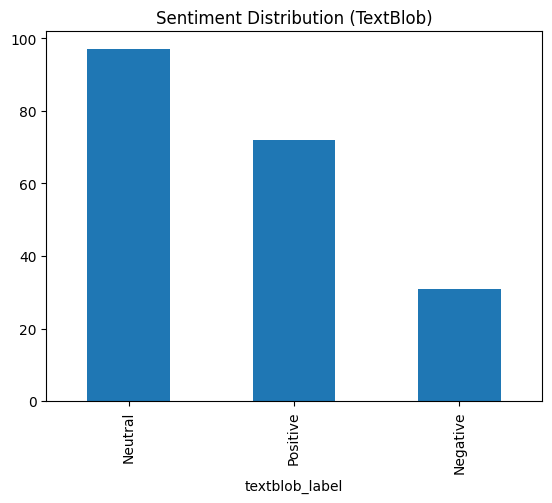

In [12]:
df["textblob_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution (TextBlob)")
plt.show()

### Sentiment Analysis using NaiveBayes Analyzer

In this step, I applied TextBlob with the NaiveBayesAnalyzer to classify each cleaned comment into sentiment categories.

Unlike polarity scoring, this method directly assigns a label (Positive or Negative) based on a trained probabilistic model. The results were stored in a new column for comparison with the TextBlob sentiment results.

In [13]:
df["nb_label"] = df["clean_comment"].apply(
    lambda x: TextBlob(x, analyzer=NaiveBayesAnalyzer()).sentiment.classification
)
display(df)

,comment,clean_comment,textblob_polarity,textblob_label,nb_label
0,*Learn Python in 1 HOUR* ⏱(2024): https://www....,learn python in hour learn numpy in hour my or...,-0.001667,Negative,pos
1,folk = 'sonion' ------- age = 67 --- ---...,folk sonion age ai baby isaah false,-0.400000,Negative,pos
2,algorithm push this,algorithm push this,0.000000,Neutral,neg
3,a random comment,a random comment,-0.500000,Negative,neg
4,hi guys ! hope you're doing well ! this is my ...,hi guys hope youre doing well this is my first...,-0.216667,Negative,pos
...,...,...,...,...,...
195,1:46:39,,0.000000,Neutral,pos
196,eeeee,eeeee,0.000000,Neutral,pos
197,"bro this is a lot betterthan most tutorials,go...",bro this is a lot betterthan most tutorialsgoo...,0.150000,Positive,neg
198,Dude you’re amazing. Thank you for taking you...,dude youre amazing thank you for taking your t...,0.212500,Positive,pos


### Sentiment Model Comparison

In this step, I compared the results from TextBlob and the NaiveBayesAnalyzer using a cross-tabulation table.

This table shows how each sentiment label from TextBlob aligns with the predictions made by the NaiveBayes model. It helps highlight similarities and differences between the two approaches for sentiment classification.

In [14]:
comparison = pd.crosstab(df["textblob_label"], df["nb_label"])
display(comparison)

nb_label,neg,pos
textblob_label,,
Negative,21,10
Neutral,32,65
Positive,24,48


### Model Comparison Visualization
In this step, I visualized the comparison between TextBlob and NaiveBayes sentiment results using a bar chart.
This plot helps to clearly see how both models classify the same comments and highlights any differences in their sentiment predictions.

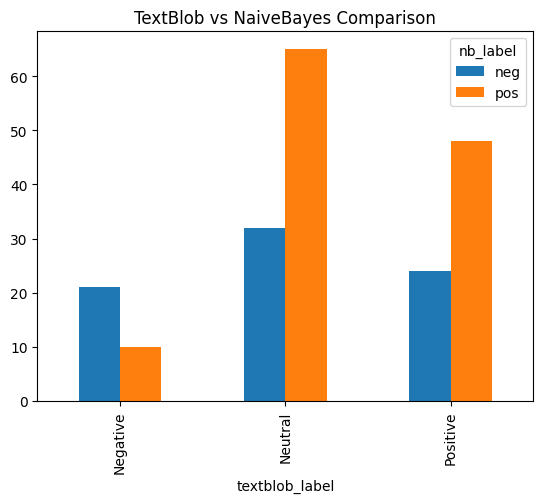

In [15]:
comparison.plot(kind="bar")
plt.title("TextBlob vs NaiveBayes Comparison")
plt.show()

### Stopwords Removal (NLTK)

I removed common English stopwords using the NLTK library. Stopwords are frequently used words (such as “the”, “is”, “and”) that do not carry strong meaning in text analysis.

Removing them helps focus on the most meaningful words in the dataset. The cleaned result was stored in a new column for further analysis and visualization.

In [16]:
stop_words = set(stopwords.words("english"))
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["no_stopwords"] = df["clean_comment"].apply(remove_stopwords)

### WordCloud Visualization

Generation of a WordCloud based on the cleaned text after stopwords removal. The visualization highlights the most frequent meaningful words appearing in the YouTube comments.

The size of each word reflects its frequency in the dataset, providing a quick overview of the most common topics and terms in the comments.

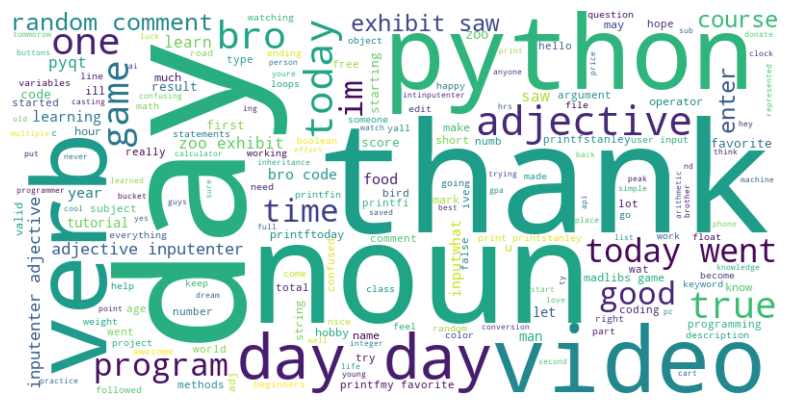

In [17]:
text = " ".join(df["no_stopwords"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Conclusion
This analysis examined sentiment in 200 YouTube comments collected using the YouTube Data API from a Python tutorial video. The dataset was cleaned to remove noise such as URLs, special characters, and unnecessary text formatting.

Sentiment analysis was performed using both TextBlob and NaiveBayesAnalyzer. The results show that most comments fall into the neutral and positive categories, indicating generally favorable audience engagement and a supportive learning community around the video content.

The comparison between models shows that NaiveBayesAnalyzer tends to classify more comments as positive compared to TextBlob, which is slightly more conservative in its predictions.

One limitation of this dataset is the presence of short and informal comments (e.g., “day 1”, “random comment”), which can reduce sentiment accuracy. Additionally, YouTube comments are highly unstructured and often contain noise or irrelevant content.

Overall, this project demonstrates how natural language processing techniques can be used to extract meaningful insights from real-world social media data.